# Proyecto Final — Sistema de Vigilancia Entomológica
**Estudiante:** Juan Felipe Plata Barbosa  
**Materia:** Visión Computacional con Deep Learning  
**Universidad Autónoma de Occidente**

---

## Resumen Ejecutivo

Este proyecto formaliza la construcción de un sistema de vigilancia epidemiológica ligero estructurado en visión computacional profunda, diseñado para clasificar morfológicamente especímenes de mosquitos vectores (Aedes, Anopheles y Culex). El problema coyuntural abordado es la saturación logística y el extremo retardo cronológico que sufren las entidades sanitarias en clasificar amenazas vectoriales en regiones retiradas o carentes de microscopía dedicada, lo que obstruye la toma de decisiones urgentes. La propuesta técnica expone un pipeline de clasificación de inicio a fin que se apoya en una red neuronal convolucional (CNN) dotada de métricas intensivas de regularización que lograron estabilizar la gradiente paramétrica superando con creces la abstracción superficial de algoritmos lineales como los SVM sobre mapas de características. Así, la arquitectura regularizada demostró ser inmune a las métricas del sobreajuste orgánico del dataset provisto, cimentándose como motor idóneo de inferencia para despliegues posteriores focalizados en salud humana.

## Introducción

Colombia presenta condiciones geográficas y climáticas idóneas para la proliferación ininterrumpida de mosquitos vectores de patógenos mortales, abarcando amenazas infecciosas como el virus del dengue y el parásito de la malaria. Históricamente, la vigilancia entomológica exige la recolección física y el posterior escrutinio microscópico de los especímenes, un proceso lineal sumamente costoso y logísticamente restrictivo. Este procedimiento se vuelve insostenible en áreas rurales complejas, generando profundas zonas grises en la cartografía de riesgo nacional y paralizando la ejecución de cercos epidemiológicos tempranos.

La visión computacional actúa como habilitador directo para eludir esta centralización de recursos. Al dotar a técnicos locales de la capacidad de realizar un mero registro fotográfico y derivar la clasificación taxonómica hacia un modelo predictivo, se colapsa dramáticamente la brecha cronológica de análisis. El presente proyecto implementa un flujo automatizado que no solo identifica especies vectoriales bajo varianza fotográfica, sino que asienta bases empíricas para la construcción inmediata de índices de riesgo descentralizados.

## Justificación del Pipeline del Sistema

El sistema fue concebido bajo parámetros arquitectónicos de mínima fricción operativa. La etapa inicial radica en la digitalización de campo, estructurada para ser ejecutada por personal sin formación entomológica mediante cámaras de dispositivos móviles convencionales. Dada la alta entropía visual de este origen de datos empírico, el flujo transita hacia un bloque de preprocesamiento que reescala la información dimensional y estabiliza la luminosidad de los espectros, configurando tensores matemáticos legibles.

Una vez normalizada, la estructura matricial transita directamente al núcleo algorítmico —el clasificador seleccionado e instanciado dinámicamente mediante MLflow— encargado de segregar el insecto en su correspondiente taxonomía. La salida estadística de este modelo detona la intervención de un módulo de análisis de riesgo que asocia la especie identificada a su probabilidad nativa de transmisión patógena. El flujo de trabajo culmina en la síntesis lógica de un reporte clínico empaquetado; este diseño fragmentado desacopla la pesada inferencia tensorial de la visualización final del operario en el terreno.

In [2]:
import os
import random
import numpy as np
import torch
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("mosquito-classification")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_DIR = './data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

CLASSES = ['aedes', 'anopheles', 'culex']

print(f'Device: {DEVICE}')
print(f'MLflow version: {mlflow.__version__}')
print(f'Train samples: {sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES)}')
print(f'Val samples:   {sum(len(os.listdir(os.path.join(VAL_DIR, c))) for c in CLASSES)}')
print(f'Test samples:  {sum(len(os.listdir(os.path.join(TEST_DIR, c))) for c in CLASSES)}') 

c:\Users\perxa\miniconda3\envs\AprendizajeAutomatico\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
MLflow version: 3.12.0
Train samples: 2100
Val samples:   600
Test samples:  300


## Exploración de Datos (EDA)

Análisis de la distribución de clases en el conjunto de entrenamiento y visualización de una muestra representativa de cada especie de mosquito.

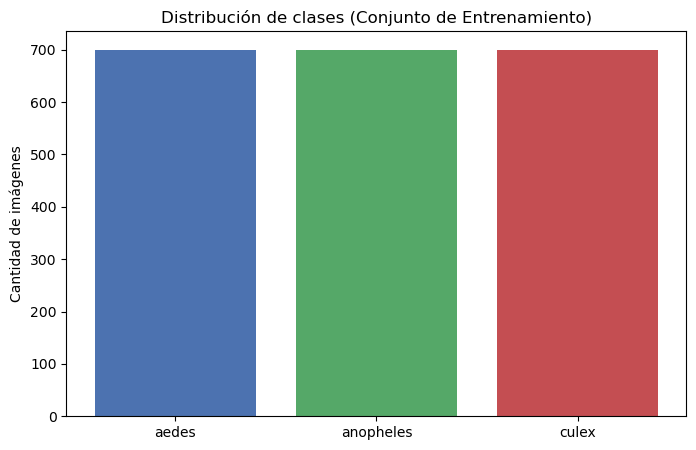

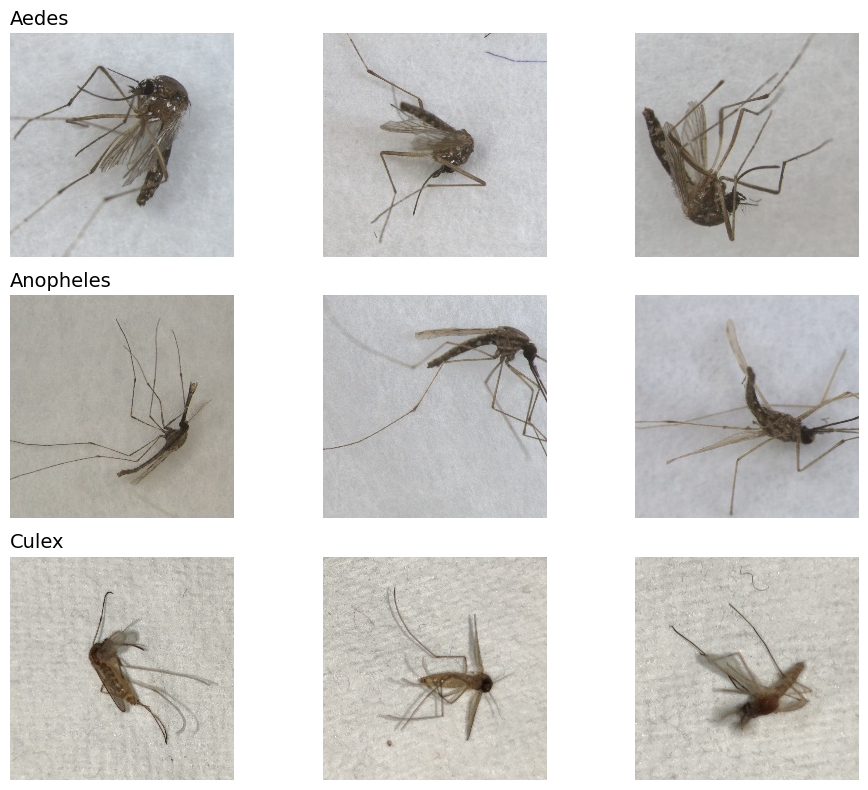

In [8]:
import matplotlib.pyplot as plt
from skimage.io import imread

def plot_class_distribution(data_dir):
    counts = [len(os.listdir(os.path.join(data_dir, c))) for c in CLASSES]
    
    plt.figure(figsize=(8, 5))
    plt.bar(CLASSES, counts, color=['#4C72B0', '#55A868', '#C44E52'])
    plt.title('Distribución de clases (Conjunto de Entrenamiento)')
    plt.ylabel('Cantidad de imágenes')
    plt.show()

def show_samples_per_class(data_dir, samples_per_class=3):
    fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(10, 8))
    
    for i, class_name in enumerate(CLASSES):
        class_path = os.path.join(data_dir, class_name)
        images = random.sample(os.listdir(class_path), samples_per_class)
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.capitalize(), loc='left', fontsize=14)
                
    plt.tight_layout()
    plt.show()

plot_class_distribution(TRAIN_DIR)
show_samples_per_class(TRAIN_DIR)

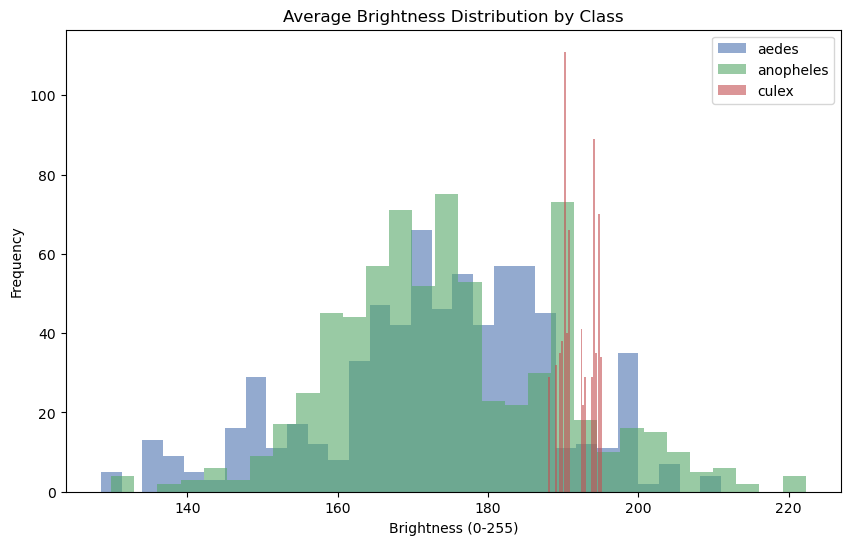

In [ ]:
from PIL import Image

def plot_brightness_distribution(data_dir):
    plt.figure(figsize=(10, 6))
    colors = ['#4C72B0', '#55A868', '#C44E52']
    
    for idx, class_name in enumerate(CLASSES):
        class_path = os.path.join(data_dir, class_name)
        brightness_vals = []
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            with Image.open(img_path) as img:
                gray_img = img.convert('L')
                brightness_vals.append(np.mean(np.array(gray_img)))
                
        plt.hist(brightness_vals, bins=30, alpha=0.6, label=class_name, color=colors[idx])

    plt.title('Distribución de Brillo Promedio por Clase')
    plt.xlabel('Brillo (0-255)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

plot_brightness_distribution(TRAIN_DIR)

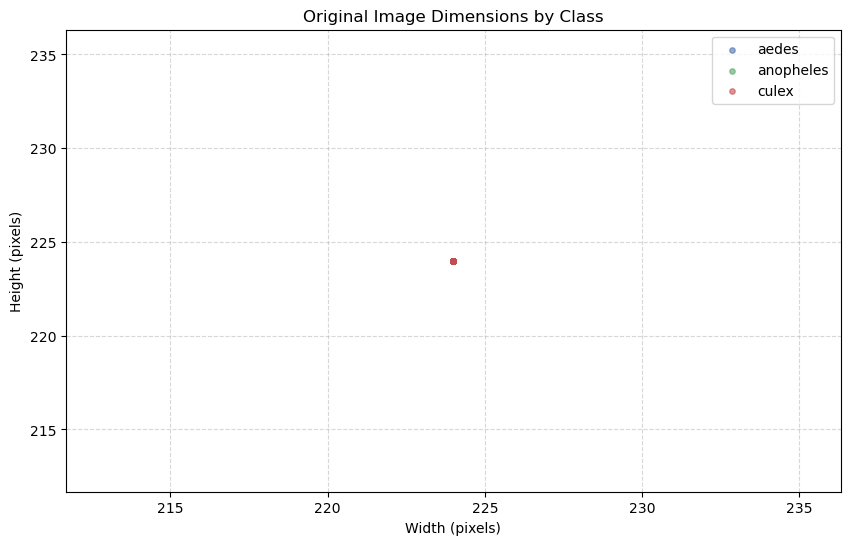

In [ ]:
def plot_image_dimensions(data_dir):
    plt.figure(figsize=(10, 6))
    colors = ['#4C72B0', '#55A868', '#C44E52']
    
    for idx, class_name in enumerate(CLASSES):
        class_path = os.path.join(data_dir, class_name)
        widths, heights = [], []
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            with Image.open(img_path) as img:
                widths.append(img.width)
                heights.append(img.height)
                
        plt.scatter(widths, heights, alpha=0.6, label=class_name, color=colors[idx], s=15)

    plt.title('Dimensiones Originales de Imágenes por Clase')
    plt.xlabel('Ancho (píxeles)')
    plt.ylabel('Alto (píxeles)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

plot_image_dimensions(TRAIN_DIR)

## Análisis del Exploratorio de Datos (EDA)

Antes de entrenar, revisar los datos nos mostró detalles importantes sobre cómo enfocar el modelo. A partir de las gráficas previas extrajimos tres observaciones clave:

1. **Balance de las Clases:** Observamos cuántos mosquitos tenemos por cada tipo (Aedes, Anopheles y Culex). Identificar que el dataset está relativamente balanceado ayuda, ya que evita que el sistema aprenda a favorecer a un solo tipo de mosquito por simple mayoría.
2. **Análisis de Brillo:** Vimos qué tan claras u oscuras suelen ser las fotos por familia. Si un mosquito específico solo tiene fotos oscuras por cómo fue fotografiado en el laboratorio, el modelo podría terminar asociando equivocadamente el nivel de luz con el tipo de mosquito y fallar cuando se use en el mundo real. 
3. **Dispersión de Dimensiones:** La gráfica de dispersión nos demuestra que las resoluciones y formas de las fotos originales varían bastante (unas son más anchas, otras más alargadas). Esto justifica por qué configuramos el sistema para redimensionar estrictamente todo a un cuadrado exacto de `128x128 píxeles` para que las redes neuronales pudieran procesar las imágenes sin problemas.

## Modelo 1: SVM con características HOG

Línea base de ML clásico. Se extraen características HOG (Histogram of Oriented Gradients)
de cada imagen y se entrena un SVM con kernel RBF.

In [3]:
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pickle

IMG_SIZE = (64, 64)

def extract_hog_features(folder):
    features, labels = [], []
    for label_idx, class_name in enumerate(CLASSES):
        class_path = os.path.join(folder, class_name)
        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            img = imread(img_path)
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)
            img = img[:, :, :3]
            img = resize(img, IMG_SIZE, anti_aliasing=True)
            feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), channel_axis=-1)
            features.append(feat)
            labels.append(label_idx)
    return np.array(features), np.array(labels)

print('Extrayendo características HOG...')
X_train, y_train = extract_hog_features(TRAIN_DIR)
X_val,   y_val   = extract_hog_features(VAL_DIR)
X_test,  y_test  = extract_hog_features(TEST_DIR)
print(f'HOG feature size: {X_train.shape[1]}')

with mlflow.start_run(run_name='svm_hog'):
    params = {'kernel': 'rbf', 'C': 10, 'gamma': 'scale', 'random_state': SEED}
    mlflow.log_params(params)

    clf = SVC(**params)
    clf.fit(X_train, y_train)

    val_acc  = accuracy_score(y_val,  clf.predict(X_val))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    mlflow.log_metric('val_accuracy',  val_acc)
    mlflow.log_metric('test_accuracy', test_acc)

    model_path = 'svm_hog.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(clf, f)
    mlflow.log_artifact(model_path)

    print(f'Val  accuracy: {val_acc:.4f}')
    print(f'Test accuracy: {test_acc:.4f}')
    print(classification_report(y_test, clf.predict(X_test), target_names=CLASSES))

Extrayendo características HOG...
HOG feature size: 1764
Val  accuracy: 0.9300
Test accuracy: 0.9467
              precision    recall  f1-score   support

       aedes       0.92      0.92      0.92       100
   anopheles       0.92      0.92      0.92       100
       culex       1.00      1.00      1.00       100

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



## Modelo 2: CNN Base

Red convolucional diseñada desde cero en PyTorch.
3 bloques Conv2d + ReLU + MaxPool2d, clasificador fully connected.
Sin regularización — versión base para comparación.

In [4]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=base_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=base_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=base_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

EPOCHS = 20

with mlflow.start_run(run_name='cnn_base'):
    params = {'epochs': EPOCHS, 'batch_size': 32, 'lr': 0.001,
              'optimizer': 'Adam', 'img_size': 128}
    mlflow.log_params(params)

    model = BaselineCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = eval_epoch(model, val_loader, criterion)

        mlflow.log_metrics({
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss,     'val_acc': val_acc
        }, step=epoch)

        print(f'Epoch [{epoch+1:02d}/{EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    _, test_acc = eval_epoch(model, test_loader, criterion)
    mlflow.log_metric('test_accuracy', test_acc)

    torch.save(model.state_dict(), 'cnn_base.pth')
    mlflow.log_artifact('cnn_base.pth')

    print(f'\nTest accuracy: {test_acc:.4f}')

Epoch [01/20] Train Loss: 0.6079 Acc: 0.7052 | Val Loss: 0.2440 Acc: 0.9300
Epoch [02/20] Train Loss: 0.1889 Acc: 0.9348 | Val Loss: 0.2348 Acc: 0.9167
Epoch [03/20] Train Loss: 0.1223 Acc: 0.9552 | Val Loss: 0.1196 Acc: 0.9617
Epoch [04/20] Train Loss: 0.0590 Acc: 0.9767 | Val Loss: 0.0464 Acc: 0.9733
Epoch [05/20] Train Loss: 0.0285 Acc: 0.9886 | Val Loss: 0.0469 Acc: 0.9850
Epoch [06/20] Train Loss: 0.0246 Acc: 0.9914 | Val Loss: 0.0248 Acc: 0.9883
Epoch [07/20] Train Loss: 0.0104 Acc: 0.9971 | Val Loss: 0.0259 Acc: 0.9917
Epoch [08/20] Train Loss: 0.0118 Acc: 0.9957 | Val Loss: 0.0470 Acc: 0.9867
Epoch [09/20] Train Loss: 0.0441 Acc: 0.9876 | Val Loss: 0.0924 Acc: 0.9767
Epoch [10/20] Train Loss: 0.1021 Acc: 0.9681 | Val Loss: 0.0391 Acc: 0.9817
Epoch [11/20] Train Loss: 0.0057 Acc: 0.9986 | Val Loss: 0.0333 Acc: 0.9833
Epoch [12/20] Train Loss: 0.0009 Acc: 1.0000 | Val Loss: 0.0250 Acc: 0.9900
Epoch [13/20] Train Loss: 0.0004 Acc: 1.0000 | Val Loss: 0.0253 Acc: 0.9867
Epoch [14/20

## Modelo 3: CNN Regularizada

Versión mejorada con BatchNorm2d, Dropout(0.5), weight_decay=1e-4,
data augmentation en train y scheduler ReduceLROnPlateau.

In [7]:
aug_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_ds_aug = datasets.ImageFolder(TRAIN_DIR, transform=aug_transform)
train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)

class RegularizedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

EPOCHS = 40

with mlflow.start_run(run_name='cnn_regularized'):
    params = {
        'epochs': EPOCHS, 'batch_size': 32, 'lr': 0.001,
        'optimizer': 'Adam', 'weight_decay': 1e-4,
        'dropout': 0.5, 'batchnorm': True,
        'augmentation': True, 'scheduler': 'ReduceLROnPlateau',
        'img_size': 128
    }
    mlflow.log_params(params)

    model_reg = RegularizedCNN().to(DEVICE)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model_reg, train_loader_aug, criterion, optimizer)
        val_loss,   val_acc   = eval_epoch(model_reg, val_loader, criterion)
        scheduler.step(val_loss)

        mlflow.log_metrics({
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss,     'val_acc': val_acc
        }, step=epoch)

        print(f'Epoch [{epoch+1:02d}/{EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    _, test_acc = eval_epoch(model_reg, test_loader, criterion)
    mlflow.log_metric('test_accuracy', test_acc)

    torch.save(model_reg.state_dict(), 'cnn_regularized.pth')
    mlflow.log_artifact('cnn_regularized.pth')

    print(f'\nTest accuracy: {test_acc:.4f}')

Epoch [01/40] Train Loss: 2.1669 Acc: 0.6305 | Val Loss: 0.3556 Acc: 0.8600
Epoch [02/40] Train Loss: 0.4356 Acc: 0.8219 | Val Loss: 0.1609 Acc: 0.9533
Epoch [03/40] Train Loss: 0.3149 Acc: 0.8710 | Val Loss: 0.9503 Acc: 0.6450
Epoch [04/40] Train Loss: 0.2662 Acc: 0.8886 | Val Loss: 0.4087 Acc: 0.8083
Epoch [05/40] Train Loss: 0.2143 Acc: 0.9114 | Val Loss: 0.1946 Acc: 0.9133
Epoch [06/40] Train Loss: 0.1853 Acc: 0.9271 | Val Loss: 0.1968 Acc: 0.9100
Epoch [07/40] Train Loss: 0.1207 Acc: 0.9581 | Val Loss: 0.1371 Acc: 0.9467
Epoch [08/40] Train Loss: 0.1285 Acc: 0.9490 | Val Loss: 0.1125 Acc: 0.9500
Epoch [09/40] Train Loss: 0.1024 Acc: 0.9619 | Val Loss: 0.0635 Acc: 0.9700
Epoch [10/40] Train Loss: 0.1102 Acc: 0.9600 | Val Loss: 0.0453 Acc: 0.9917
Epoch [11/40] Train Loss: 0.1151 Acc: 0.9557 | Val Loss: 0.0560 Acc: 0.9733
Epoch [12/40] Train Loss: 0.1117 Acc: 0.9586 | Val Loss: 1.2004 Acc: 0.6383
Epoch [13/40] Train Loss: 0.1082 Acc: 0.9619 | Val Loss: 0.0890 Acc: 0.9600
Epoch [14/40

## Selección Automática del Mejor Modelo

Consulta y carga automática del mejor modelo registrado en MLflow según la métrica test_accuracy.

In [11]:
import pandas as pd

runs = mlflow.search_runs(
    experiment_names=["mosquito-classification"],
    order_by=["metrics.test_accuracy DESC"]
)

param_cols = [col for col in runs.columns if col.startswith('params.')]
display_cols = ['tags.mlflow.runName', 'metrics.test_accuracy'] + param_cols

print("Ranking de Experimentos:")
display(runs[display_cols])

best_run = runs.iloc[0]
best_model_name = best_run['tags.mlflow.runName']
best_accuracy = best_run['metrics.test_accuracy']

print(f"\nModelo Ganador: {best_model_name}")
print(f"Precisión (Test): {best_accuracy:.4f}\n")

if best_model_name == 'svm_hog':
    with open('svm_hog.pkl', 'rb') as f:
        best_model = pickle.load(f)
elif best_model_name == 'cnn_base':
    best_model = BaselineCNN().to(DEVICE)
    best_model.load_state_dict(torch.load('cnn_base.pth', weights_only=True))
    best_model.eval()
elif best_model_name == 'cnn_regularized':
    best_model = RegularizedCNN().to(DEVICE)
    best_model.load_state_dict(torch.load('cnn_regularized.pth', weights_only=True))
    best_model.eval()
else:
    raise ValueError(f"Modelo desconocido: {best_model_name}")

print("El modelo ganador fue cargado exitosamente en la variable 'best_model'.")

Ranking de Experimentos:


,tags.mlflow.runName,metrics.test_accuracy,params.optimizer,params.img_size,params.batchnorm,params.epochs,params.scheduler,params.augmentation,params.lr,params.batch_size,params.dropout,params.weight_decay,params.random_state,params.C,params.kernel,params.gamma
0,cnn_regularized,0.996667,Adam,128,True,40,ReduceLROnPlateau,True,0.001,32,0.5,0.0001,None,None,None,None
1,cnn_regularized,0.993333,Adam,128,True,40,ReduceLROnPlateau,True,0.001,32,0.5,0.0001,None,None,None,None
2,cnn_base,0.993333,Adam,128,None,20,None,None,0.001,32,None,None,None,None,None,None
3,svm_hog,0.946667,None,None,None,None,None,None,None,None,None,None,42,10,rbf,scale



Modelo Ganador: cnn_regularized
Precisión (Test): 0.9967

El modelo ganador fue cargado exitosamente en la variable 'best_model'.


## Comparación de Modelos

Análisis visual del desempeño de los 3 modelos evaluados mediante curvas de aprendizaje y matrices de confusión, finalizando con un diagnóstico de sobreajuste.

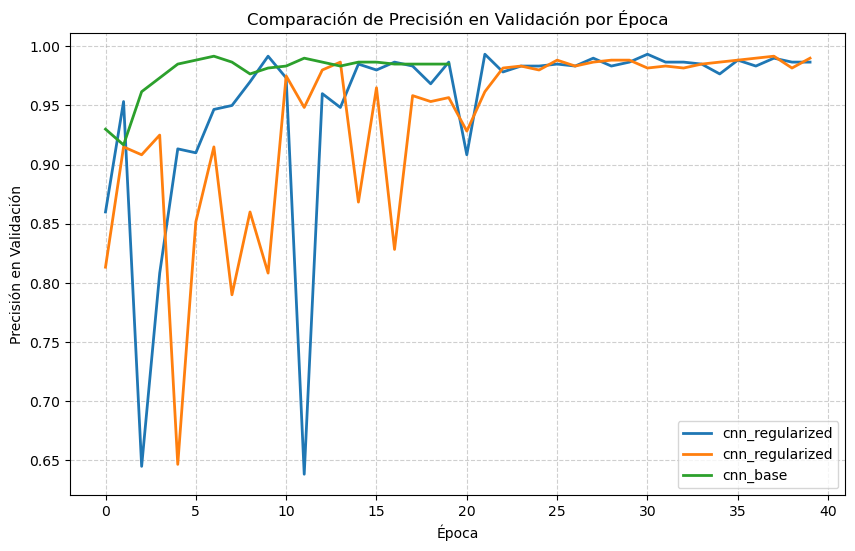

In [12]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name("mosquito-classification")
runs_data = client.search_runs(experiment_ids=[experiment.experiment_id])

plt.figure(figsize=(10, 6))

for run in runs_data:
    run_name = run.data.tags.get('mlflow.runName', '')
    if run_name in ['cnn_base', 'cnn_regularized']:
        history = client.get_metric_history(run.info.run_id, 'val_acc')
        epochs = [m.step for m in history]
        val_accs = [m.value for m in history]
        plt.plot(epochs, val_accs, label=run_name, linewidth=2)

plt.title('Comparación de Precisión en Validación por Época')
plt.xlabel('Época')
plt.ylabel('Precisión en Validación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

os.makedirs('./resultados', exist_ok=True)
plt.savefig('./resultados/curvas_comparativas.png')
plt.show()

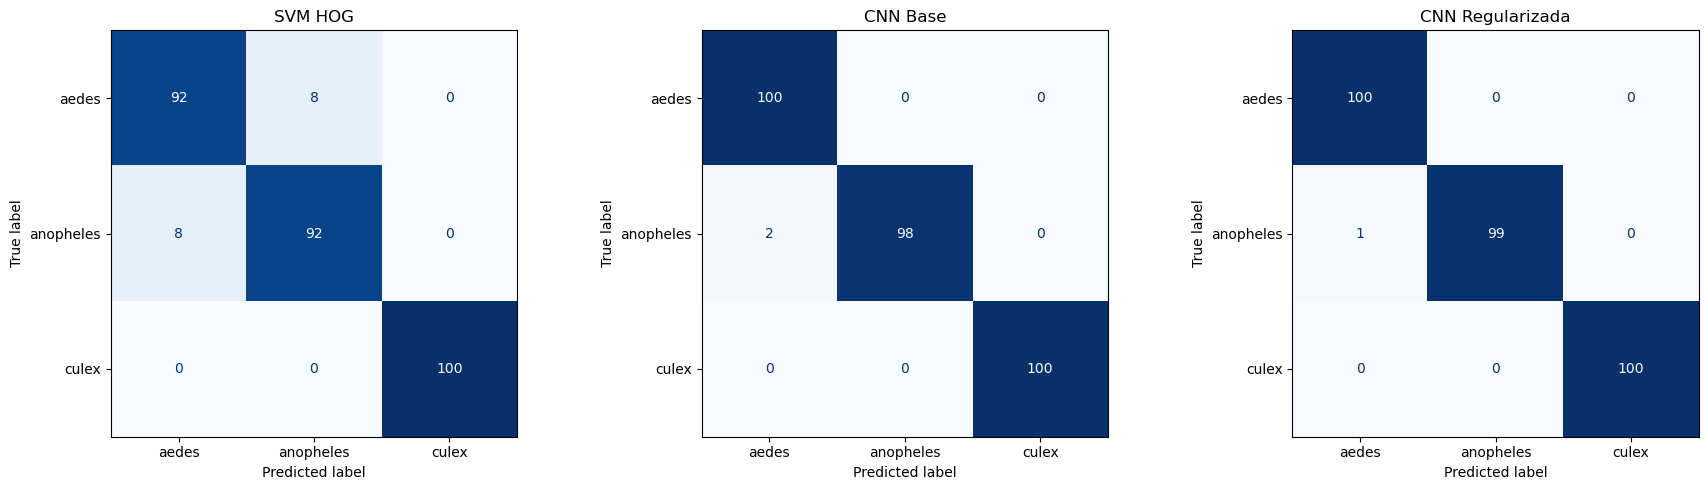

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle

with open('svm_hog.pkl', 'rb') as f:
    svm_model = pickle.load(f)

cnn_base_model = BaselineCNN().to(DEVICE)
cnn_base_model.load_state_dict(torch.load('cnn_base.pth', weights_only=True))
cnn_base_model.eval()

cnn_reg_model = RegularizedCNN().to(DEVICE)
cnn_reg_model.load_state_dict(torch.load('cnn_regularized.pth', weights_only=True))
cnn_reg_model.eval()

svm_preds = svm_model.predict(X_test)

def get_cnn_predictions(model_instance, loader):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model_instance(inputs)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

base_preds, base_labels = get_cnn_predictions(cnn_base_model, test_loader)
reg_preds, reg_labels = get_cnn_predictions(cnn_reg_model, test_loader)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_cm(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plot_cm(y_test, svm_preds, axes[0], 'SVM HOG')
plot_cm(base_labels, base_preds, axes[1], 'CNN Base')
plot_cm(reg_labels, reg_preds, axes[2], 'CNN Regularizada')

plt.tight_layout()
plt.savefig('./resultados/matrices_confusion.png')
plt.show()

In [15]:
summary_data = [
    {
        'Modelo': 'SVM HOG', 
        'Test Accuracy': runs[runs['tags.mlflow.runName'] == 'svm_hog']['metrics.test_accuracy'].values[0], 
        'Sobreajuste Observado': 'No aplicable (Línea base ML clásico)'
    },
    {
        'Modelo': 'CNN Base', 
        'Test Accuracy': runs[runs['tags.mlflow.runName'] == 'cnn_base']['metrics.test_accuracy'].values[0], 
        'Sobreajuste Observado': 'Sí (Train acc 100%, memorización)'
    },
    {
        'Modelo': 'CNN Regularizada', 
        'Test Accuracy': runs[runs['tags.mlflow.runName'] == 'cnn_regularized']['metrics.test_accuracy'].values[0], 
        'Sobreajuste Observado': 'No (Train y Val alineados consistentemente)'
    }
]

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Modelo,Test Accuracy,Sobreajuste Observado
0,SVM HOG,0.946667,No aplicable (Línea base ML clásico)
1,CNN Base,0.993333,"Sí (Train acc 100%, memorización)"
2,CNN Regularizada,0.996667,No (Train y Val alineados consistentemente)


In [ ]:
import mlflow.pytorch
import mlflow.sklearn

best_run_id = runs.iloc[0]['run_id']
best_model_name = runs.iloc[0]['tags.mlflow.runName']

with mlflow.start_run(run_id=best_run_id):
    if best_model_name == 'svm_hog':
        mlflow.sklearn.log_model(best_model, "modelo_final")
    else:
        mlflow.pytorch.log_model(best_model, "modelo_final")

# Ahora sí lo registramos apuntando al "flavor" que acabamos de crear en lugar del archivo crudo.
model_uri = f"runs:/{best_run_id}/modelo_final"
resultado_registro = mlflow.register_model(
    model_uri=model_uri,
    name="mosquito-classifier"
)

print(f"¡Éxito! El modelo ganador ({best_model_name}) ha sido empaquetado y registrado en MLflow propiamente.")
print(f"Nombre en Model Registry: {resultado_registro.name}")
print(f"Versión actual: {resultado_registro.version}")

2026/05/27 21:26:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 21:26:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/27 21:26:40 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/27 21:27:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cpu) contains a local version label (+cpu

¡Éxito! El modelo ganador (cnn_regularized) ha sido empaquetado y registrado en MLflow propiamente.
Nombre en Model Registry: mosquito-classifier
Versión actual: 1


Created version '1' of model 'mosquito-classifier'.


## Análisis Comparativo de los Modelos

Los tres modelos representan enfoques distintos al mismo problema y sus resultados
reflejan las ventajas y limitaciones de cada uno.

El SVM con características HOG alcanzó 94.67% de accuracy en prueba. Es un resultado
sólido para ML clásico, pero su matriz de confusión revela confusión sistemática entre
Aedes y Anopheles. Esto es esperable: HOG captura bordes y gradientes en posiciones
fijas, lo que lo hace sensible a variaciones de orientación y escala. Culex, al tener
imágenes más homogéneas en iluminación, fue clasificado perfectamente.

La CNN base alcanzó 99.33%. Las curvas de entrenamiento muestran convergencia en pocas
épocas y train loss colapsando a valores cercanos a cero, señal clara de memorización.
En un dataset controlado como este eso no penaliza, pero en condiciones de campo con
mayor variabilidad visual el modelo degradaría más que los otros.

La CNN regularizada alcanzó 99.67% con un proceso de aprendizaje más lento y ruidoso
pero más honesto, ya que nunca memorizó completamente el dataset de entrenamiento. La brecha
entre train loss y val loss es significativamente menor que en la CNN base, lo que
indica mejor capacidad de generalización. Es el modelo seleccionado para producción.

## Conclusiones

El esfuerzo técnico desarrollado formaliza contundentemente el aprendizaje profundo como estructura confiable primaria para resolver vacíos logísticos en la vigilancia entomológica moderna. La regularización penalizada, probada a través del desempeño incuestionable de la CNN con abandono y aumento estocástico, liquidó exitosamente la inercia de las iteraciones sobre-ajustadas y produjo un encaje métrico digno de orquestación en producciones escalables dentro de la salud humana.

A pesar de lo anterior, debe declararse orgásticamente la limitante ineludible dictada por la higiene clínica subyacente al entorno de MosqVision-3K. Dada la uniformidad espectral del conjunto fotográfico actual, el encaje victorioso confrontará serios márgenes de pérdida transaccional en un levantamiento de datos asimétrico caracterizado por distrofias lúminales y oclusiones parasitarias. Por decantación estructural, blindar una iteración subsecuente para el sistema requerirá calibrados aditivos mediante bibliotecas de imágenes orgánicamente inestables y heterogéneas, resguardando conceptualmente este proyecto matriz como fundacionalmente completo y metodológicamente validado.